In [ ]:
# Cell 1 - Import Libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import warnings
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
from tensorflow.keras.regularizers import l2
warnings.filterwarnings('ignore')



In [ ]:
# # Cell 2 - Mount Google Drive (jika menggunakan Colab)
# from google.colab import drive
# drive.mount('/content/drive')



In [ ]:
# Cell 3 - Definisi Fungsi Utility
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(
            f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'."
        )

def count_images(directory, classes):
    counts = []
    total_count = 0
    for scene_class in classes:
        class_path = os.path.join(directory, scene_class)
        num_images = len(os.listdir(class_path))
        counts.append(num_images)
        total_count += num_images
    counts.append(total_count)
    return counts

def plot_scene_distribution(train_dir, test_dir, classes):
    colors = ['blue', 'green']
    train_counts = count_images(train_dir, classes)
    test_counts = count_images(test_dir, classes)

    fig, ax = plt.subplots(figsize=(10, 6))
    bar_width = 0.35
    index = np.arange(len(classes) + 1)

    for i, (counts, color, label) in enumerate(zip([train_counts, test_counts], colors, ['Train', 'Test'])):
        ax.bar(index + i * bar_width, counts, bar_width, label=label, color=color)
        for j, count in enumerate(counts):
            ax.text(j + i * bar_width, count + 10, str(count), ha='center', va='bottom')

    ax.set_xlabel('Scene Classes')
    ax.set_ylabel('Number of Images')
    ax.set_title('Distribution of Images in Train and Test Sets')
    ax.set_xticks(index + bar_width / 2)
    ax.set_xticklabels(classes + ['Total'])
    ax.legend()
    plt.show()



In [ ]:
# Cell 4 - Set Path dan Plot Distribution
training_data = 'training_data'
test_data = 'test_data'
classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']




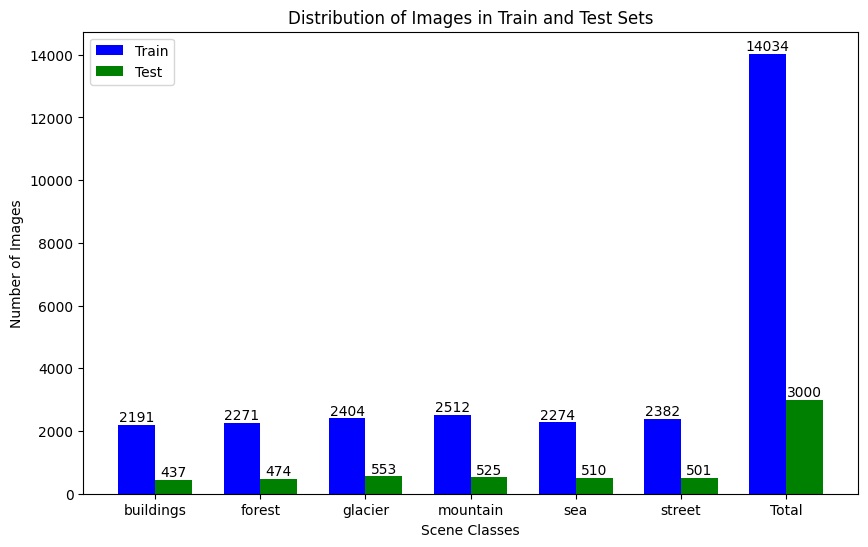

In [ ]:

plot_scene_distribution(training_data, test_data, classes)

In [ ]:
# Cell 5 - Set Hyperparameters dan Random Seed
IMG_HEIGHT = 100
IMG_WIDTH = 100
BATCH_SIZE = 32  # Dikurangi untuk memori yang lebih efisien
EPOCHS = 30
FINE_TUNING_EPOCHS = 20
LR = 0.001
NUM_CLASSES = 6




In [ ]:
import random
tf.keras.utils.set_random_seed(42)
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)



In [ ]:
# Cell 6 - Data Preprocessing dan Generator
preprocess = tf.keras.applications.vgg16.preprocess_input

train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.05,
    rotation_range=20,
    preprocessing_function=preprocess,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess)

train_generator = train_datagen.flow_from_directory(
    directory=training_data,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    color_mode="rgb",
    class_mode="categorical",
    subset="training",
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    directory=training_data,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    color_mode="rgb",
    class_mode="categorical",
    subset="validation",
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    directory=test_data,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    color_mode="rgb",
    class_mode="categorical",
    seed=42
)



Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# Cell 7 - Model Architecture
def feature_extractor(inputs):
    feature_extractor = tf.keras.applications.VGG16(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights="imagenet"
    )(inputs)
    return feature_extractor

def classifier(inputs):
    x = tf.keras.layers.Conv2D(512, (3, 3), activation="relu", padding="same",kernel_regularizer=l2(0.01))(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    x = tf.keras.layers.Conv2D(512, (3, 3), activation="relu", padding="same", kernel_regularizer=l2(0.01))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    x = tf.keras.layers.Conv2D(NUM_CLASSES, (1, 1), padding="same")(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Activation("softmax", name="classification")(x)

    return x

def final_model(inputs):
    vgg_feature_extractor = feature_extractor(inputs)
    classification_output = classifier(vgg_feature_extractor)
    return classification_output

def define_compile_model():
    inputs = tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    classification_output = final_model(inputs)
    model = tf.keras.Model(inputs=inputs, outputs=classification_output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



In [ ]:
# Cell 8 - Define Model dan Print Summary
model = define_compile_model()
model.layers[1].trainable = False

print("\nModel Architecture:")
model.summary()




Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 6)        │         3,078 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 6)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Activation)     │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,478 (74.16 MB)

 Trainable params: 4,724,742 (18.02 MB)

 Non-trainable params: 14,716,736 (56.14 MB)

In [ ]:
# Cell 9 - Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    min_delta=0.001,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)



In [ ]:
# Cell 10 - Initial Training
print("\nInitial training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)



Initial training...
Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.8024 - loss: 5.7916
Epoch 1: val_accuracy improved from -inf to 0.79672, saving model to best_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 276s 780ms/step - accuracy: 0.8024 - loss: 5.7845 - val_accuracy: 0.7967 - val_loss: 1.4450 - learning_rate: 0.0010
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.8417 - loss: 1.2884
Epoch 2: val_accuracy improved from 0.79672 to 0.84843, saving model to best_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 281s 801ms/step - accuracy: 0.8417 - loss: 1.2883 - val_accuracy: 0.8484 - val_loss: 1.2781 - learning_rate: 0.0010
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.8502 - loss: 1.1919
Epoch 3: val_accuracy improved from 0.84843 to 0.85521, saving model to best_model.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 303s 863ms/step - accuracy: 0.8502 - loss: 1.1919 - val_accuracy: 0.8552 - val_loss: 1.0715 - learning_rate: 0.0010
Epoch 4/30
351/3

In [ ]:

# Cell 11 - Fine-tuning
print("\nFine-tuning...")
for layer in model.layers[1].layers[-4:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture after unfreezing layers:")
model.summary()

history_fine_tune = model.fit(
    train_generator,
    epochs=FINE_TUNING_EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)



Fine-tuning...

Model Architecture after unfreezing layers:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 6)        │         3,078 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 6)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Activation)     │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,478 (74.16 MB)

 Trainable params: 11,804,166 (45.03 MB)

 Non-trainable params: 7,637,312 (29.13 MB)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.8873 - loss: 0.4501
Epoch 1: val_accuracy did not improve from 0.90977
351/351 ━━━━━━━━━━━━━━━━━━━━ 400s 1s/step - accuracy: 0.8874 - loss: 0.4501 - val_accuracy: 0.8609 - val_loss: 0.5177 - learning_rate: 1.0000e-04
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.9176 - loss: 0.3639
Epoch 2: val_accuracy did not improve from 0.90977
351/351 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.9176 - loss: 0.3639 - val_accuracy: 0.8937 - val_loss: 0.4255 - learning_rate: 1.0000e-04
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.9249 - loss: 0.3233
Epoch 3: val_accuracy did not improve from 0.90977
351/351 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.9249 - loss: 0.3233 - val_accuracy: 0.9044 - val_loss: 0.3761 - learning_rate: 1.0000e-04
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 970ms/step - accuracy: 0.9337 - loss: 0.2908
Epoch 4: val_accuracy did not improve from 0.90977
351/35

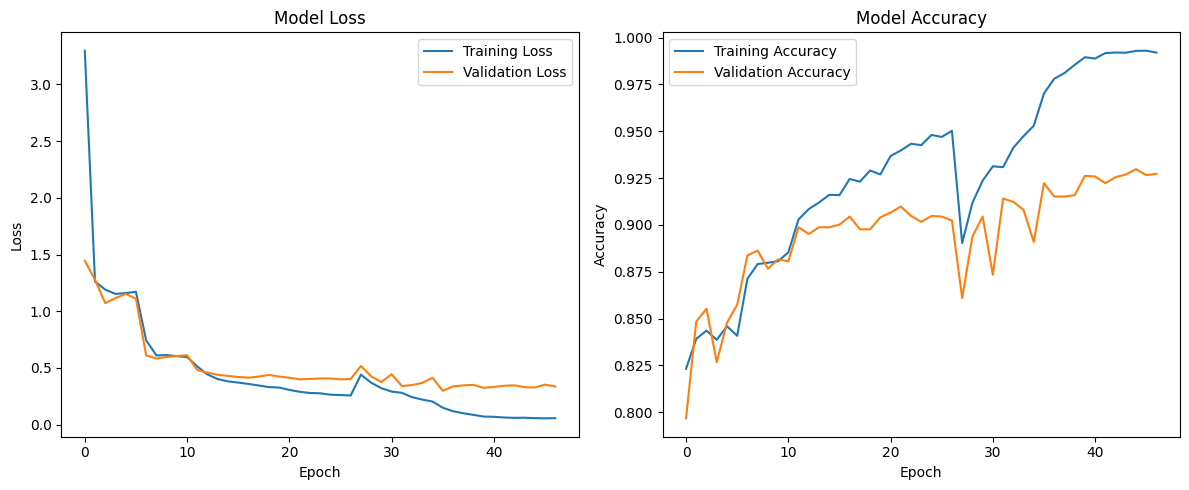

In [ ]:

# Cell 12 - Plot Training History
history_combined = {}
for key in history.history:
    history_combined[key] = history.history[key] + history_fine_tune.history[key]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_combined['loss'], label='Training Loss')
plt.plot(history_combined['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_combined['accuracy'], label='Training Accuracy')
plt.plot(history_combined['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
preds_ts = model.predict(test_generator)
y_preds_ts = np.argmax(preds_ts , axis=1)
y_test = np.array(test_generator.labels)

preds_tr = model.predict(train_generator)
y_preds_tr = np.argmax(preds_tr , axis=1)
y_train = np.array(train_generator.labels)

preds_vl = model.predict(validation_generator)
y_preds_vl = np.argmax(preds_vl , axis=1)
y_validation = np.array(validation_generator.labels)

94/94 ━━━━━━━━━━━━━━━━━━━━ 55s 580ms/step
351/351 ━━━━━━━━━━━━━━━━━━━━ 200s 571ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 53s 605ms/step


In [ ]:
loss, accuracy = model.evaluate(train_generator)
print(f" Training Loss: {loss}, Training Accuracy: {accuracy}")

351/351 ━━━━━━━━━━━━━━━━━━━━ 212s 603ms/step - accuracy: 0.9948 - loss: 0.0520
 Training Loss: 0.05247209593653679, Training Accuracy: 0.9943009614944458


In [ ]:
def percentage_and_round(value):
    return round(value * 100, 2)

test_accuracy = percentage_and_round(accuracy_score(y_test, y_preds_ts))
print(f"Test Accuracy: {test_accuracy}%")
print("Classification Report (Test):")
classification_report_test = classification_report(y_test, y_preds_ts, output_dict=True)
for label, metrics in classification_report_test.items():
    if isinstance(metrics, dict):
        print(f"{label}: {percentage_and_round(metrics['precision'])}% Precision, {percentage_and_round(metrics['recall'])}% Recall, {percentage_and_round(metrics['f1-score'])}% F1-Score")


Test Accuracy: 92.63%
Classification Report (Test):
0: 90.29% Precision, 93.59% Recall, 91.91% F1-Score
1: 98.95% Precision, 99.79% Recall, 99.37% F1-Score
2: 88.93% Precision, 87.16% Recall, 88.04% F1-Score
3: 88.93% Precision, 88.76% Recall, 88.85% F1-Score
4: 94.55% Precision, 95.29% Recall, 94.92% F1-Score
5: 94.68% Precision, 92.42% Recall, 93.54% F1-Score
macro avg: 92.72% Precision, 92.84% Recall, 92.77% F1-Score
weighted avg: 92.63% Precision, 92.63% Recall, 92.62% F1-Score


In [ ]:
validation_accuracy = percentage_and_round(accuracy_score(y_validation, y_preds_vl))
print(f"Validation Accuracy: {validation_accuracy}%")
print("Classification Report (Validation):")
classification_report_validation = classification_report(y_validation, y_preds_vl, output_dict=True)
for label, metrics in classification_report_validation.items():
    if isinstance(metrics, dict):
        print(f"{label}: {percentage_and_round(metrics['precision'])}% Precision, {percentage_and_round(metrics['recall'])}% Recall, {percentage_and_round(metrics['f1-score'])}% F1-Score")



Validation Accuracy: 92.62%
Classification Report (Validation):
0: 94.21% Precision, 92.92% Recall, 93.56% F1-Score
1: 98.24% Precision, 98.46% Recall, 98.35% F1-Score
2: 87.66% Precision, 87.29% Recall, 87.47% F1-Score
3: 87.4% Precision, 88.45% Recall, 87.92% F1-Score
4: 95.15% Precision, 95.15% Recall, 95.15% F1-Score
5: 93.92% Precision, 94.12% Recall, 94.02% F1-Score
macro avg: 92.76% Precision, 92.73% Recall, 92.75% F1-Score
weighted avg: 92.63% Precision, 92.62% Recall, 92.62% F1-Score


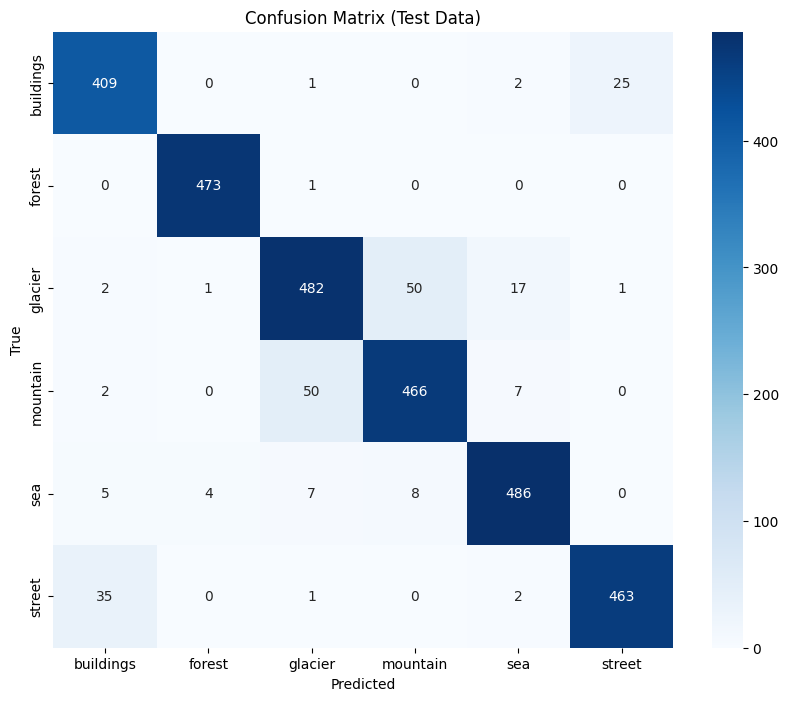

In [ ]:
cm_ts = confusion_matrix(y_test, y_preds_ts)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ts, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Data)')
plt.show()